# Training GCN Model (reference)

## Import Lib and define paths

In [1]:
# === Path Variables ===# Healthy

import os  # For handling file paths and directories
import pandas as pd  # For working with tabular data using DataFrames
import matplotlib.pyplot as plt  # For generating plots
import seaborn as sns  # For enhanced visualizations of heatmaps
import zipfile  # For reading compressed files without extracting them
import re  # For extracting numerical IDs using regular expressions

import torch
import random
import numpy as np

import os
import pandas as pd
import numpy as np

import networkx as nx  # For graph-level metrics


BASE_DIR = "../../../input_columns_1mm/input_columns"
SUBJECT_IDS_CSV = "../../age_prediction_on_columns_analyses/subject_ids.csv"
AGE_CSV = "../../age_prediction_on_columns_analyses/ages.csv"
THICKNESS_DIR = '../../../thickness_in_region'
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
age_df = pd.read_csv(AGE_CSV, header=None)
metadata_path = "../../../AD_DECODE_data3.xlsx"
df_metadata = pd.read_excel(metadata_path)


## Delete the abnormal QSM subjects

In [2]:
# The abnormal QSM subjects list
abnormal_qsm_subjects = [2765, 2320, 3343, 3350, 1412
                         , 1619, 3866, 2231]
# Delete the abnormal QSM subjects from the subject_df
subject_df = subject_df[~subject_df[0].isin(abnormal_qsm_subjects)]

In [3]:
# === Set seed for reproducibility ===
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

#Load columns

# Base directory where subject folders (e.g., S00775_columns_1mm) are stored


In [4]:
# List of hemispheres
HEMIS = ["lh", "rh"]


In [5]:
# List of cortical regions (based on the parcellation used)
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

In [6]:
############################## METADATA ##############################

print("ADDECODE METADATA\n")

ADDECODE METADATA



In [7]:
# Zero-pad subject IDs to 5-digit strings
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()

In [8]:
# Standardize MRI_Exam IDs
df_metadata["MRI_Exam_fixed"] = (
    df_metadata["MRI_Exam"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)



In [9]:
# Drop fully empty rows and rows missing MRI_Exam
df_metadata_cleaned = df_metadata.dropna(how="all")
df_metadata_cleaned = df_metadata_cleaned.dropna(subset=["MRI_Exam"])


In [10]:
# === Filter metadata to match only included subject IDs ===
df_matched = df_metadata_cleaned[df_metadata_cleaned["MRI_Exam_fixed"].isin(subject_ids)].copy()


In [11]:
# === Only keep valid IDs for reordering to avoid KeyError ===
valid_ids = [sid for sid in subject_ids if sid in df_matched["MRI_Exam_fixed"].values]


In [12]:
# === Reorder safely ===
df_matched = df_matched.set_index("MRI_Exam_fixed").loc[valid_ids].reset_index()


In [13]:
# === Clean 'Risk' column: treat NaNs and empty strings as 'NoRisk' ===
df_matched["Risk"] = (
    df_matched["Risk"]
    .fillna("NoRisk")                              # Replace NaNs
    .replace(r'^\s*$', "NoRisk", regex=True)       # Replace empty strings or whitespace
    .str.strip()                                   # Remove leading/trailing spaces
)


In [14]:
# === Filter only healthy or familial risk subjects ===
df_matched_filtered = df_matched[df_matched["Risk"].isin(["NoRisk", "Familial"])].copy()


In [15]:
# === Print summary ===
print("Remaining risk group distribution:")
print(df_matched_filtered["Risk"].value_counts())
print(f"\nSubjects before filtering: {len(df_matched)}")
print(f"Subjects after filtering:  {len(df_matched_filtered)}")


Remaining risk group distribution:
Risk
Familial    42
NoRisk      17
Name: count, dtype: int64

Subjects before filtering: 64
Subjects after filtering:  59


In [16]:
# Build age_dict from the healthy metadata dataframe
age_dict = dict(zip(df_matched_filtered["MRI_Exam_fixed"], df_matched_filtered["age"]))


In [17]:
# === Extract filtered subject IDs (already cleaned and filtered to NoRisk / Familial) ===
subject_ids = df_matched_filtered["MRI_Exam_fixed"].tolist()


In [18]:
# === Initialize final dictionary: subject_id -> region -> matrix ===
column_data = {}


In [19]:
# === Loop through filtered subjects ===
for subj_id in subject_ids:
    subj_dict = {}
    subj_dir = os.path.join(BASE_DIR, f"S{subj_id}_columns_1mm")  # Path to subject's folder
    subj_dir_to_thickness = os.path.join(THICKNESS_DIR, f"S{subj_id}")  # Path to subject's thickness folder

    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            thickness_filename = f"S{subj_id}{region_key}_thickness.csv"
            # Construct full file path
            thickness_filepath = os.path.join(subj_dir_to_thickness, thickness_filename)
            if not os.path.exists(thickness_filepath):
                print(f"[WARNING] Missing thickness file: {thickness_filepath}")
                continue

            # Load the thickness CSV matrix and get the mean thickness value
            thickness_mat = pd.read_csv(thickness_filepath, header=None).values.astype(np.float32)
            if thickness_mat.size == 0:
                print(f"[WARNING] Empty thickness matrix for {thickness_filepath}")
                continue
            # Calculate mean thickness for the region
            mean_thickness = np.mean(thickness_mat)
            subj_dict[region_key] = mean_thickness

    if len(subj_dict) > 0:
        column_data[subj_id] = subj_dict
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")



In [20]:
#####################  DEVICE CONFIGURATION  #######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [21]:
#DEFINE MODEL GCNs
import torch
import torch.nn as nn

class ThicknessNet(nn.Module):
    def __init__(self, thickness_dim=68):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(thickness_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, thickness):
        return self.fc(thickness)


In [31]:
  #train and eval funcions  
    
from torch.optim import Adam
from torch_geometric.loader import DataLoader  # Usamos el DataLoader de torch_geometric

def train(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)  # GPU
        optimizer.zero_grad()
        output = model(data.x).view(-1)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, test_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)  # GPU
            output = model(data.x).view(-1)
            loss = criterion(output, data.y)
            total_loss += loss.item()
    return total_loss / len(test_loader)


In [54]:
def standard_scale_thickness_dict(thickness_dict, save_stats=True, stats_filename="thickness_scaling_stats.csv"):
    """
    Apply standard scaling to thickness values across all subjects and regions
    
    Args:
        thickness_dict: Dictionary of thickness values
        save_stats: Whether to save global mean and std to CSV
        stats_filename: Filename for saving statistics
    
    Returns:
        scaled thickness_dict and tuple of (global_mean, global_std)
    """
    # First, collect all thickness values across all subjects and regions
    all_thickness_values = []
    for subj_id, region_data in thickness_dict.items():
        for region_key, thickness_value in region_data.items():
            all_thickness_values.append(thickness_value)
    
    # Calculate global mean and std
    all_thickness_array = np.array(all_thickness_values)
    global_mean = np.mean(all_thickness_array)
    global_std = np.std(all_thickness_array)
    
    print(f"Thickness scaling statistics:")
    print(f"  Global mean: {global_mean:.6f}")
    print(f"  Global std:  {global_std:.6f}")
    print(f"  Total values: {len(all_thickness_values)}")
    
    # Save statistics to CSV if requested
    if save_stats:
        stats_df = pd.DataFrame({
            'statistic': ['mean', 'std', 'count'],
            'value': [global_mean, global_std, len(all_thickness_values)]
        })
        stats_df.to_csv(stats_filename, index=False)
        print(f"  Saved scaling statistics to: {stats_filename}")
    
    # Apply scaling to each subject's thickness values
    for subj_id, region_data in thickness_dict.items():
        for region_key, thickness_value in region_data.items():
            if global_std != 0:
                thickness_dict[subj_id][region_key] = (thickness_value - global_mean) / global_std
            else:
                thickness_dict[subj_id][region_key] = 0.0
    
    return thickness_dict, (global_mean, global_std)

column_data, thickness_stats = standard_scale_thickness_dict(
    column_data, 
    save_stats=True, 
    stats_filename="thickness_scaling_stats.csv"
)

Thickness scaling statistics:
  Global mean: 2.870124
  Global std:  0.481487
  Total values: 4012
  Saved scaling statistics to: thickness_scaling_stats.csv


In [55]:
#Training
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# Training settings
epochs = 300
patience = 40
k = 7  # Number of folds
batch_size = 6

# === Initialize loss and tracking ===
all_train_losses = []
all_test_losses = []
all_early_stopping_epochs = []

# === Extract subject IDs from thickness data ===
thickness_subject_ids = [subj_id for subj_id in subject_ids]

# === Get matching ages in the same order ===
ages = np.array([age_dict[subj_id] for subj_id in thickness_subject_ids])

# === Create age bins for stratification ===
age_bins = pd.qcut(ages, q=5, labels=False)  # 5 quantiles
thickness_data_list = []
for subj_id in subject_ids:
    subj_thickness = []
    subj_dict = column_data[subj_id]
    # Ensure all regions are present and ordered
    for region_key in region_keys:
        subj_thickness.append(subj_dict.get(region_key, 0.0))  # Use 0.0 if missing
    thickness_tensor = torch.tensor(subj_thickness, dtype=torch.float32)
    age_tensor = torch.tensor([age_dict[subj_id]], dtype=torch.float32)
    # Create a torch_geometric Data object
    data = Data(x=thickness_tensor.unsqueeze(0), y=age_tensor)
    data.subject_id = subj_id
    thickness_data_list.append(data)

In [56]:
# Final check
print("Total subjects:", len(thickness_data_list))
print("Total age bins:", len(age_bins))

from sklearn.model_selection import StratifiedKFold
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
import torch
import numpy as np
from torch_geometric.loader import DataLoader



Total subjects: 59
Total age bins: 59


In [57]:
# Stratified split by age bins
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
repeats_per_fold = 10


In [58]:
# === Build age vector and age bins ===
thickness_subject_ids = [subj_id for subj_id in subject_ids]
ages = np.array([age_dict[subj_id] for subj_id in thickness_subject_ids])
age_bins = pd.qcut(ages, q=5, labels=False)

for fold in range(k):
    train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
    test_idx = np.loadtxt(f"../set_split/test_indices_fold_{fold}.csv", delimiter=",", dtype=int)
    print(f"\n=== Fold {fold+1}/{k} ===")

    train_data = [thickness_data_list[i] for i in train_idx]
    test_data = [thickness_data_list[i] for i in test_idx]

    fold_train_losses = []
    fold_test_losses = []

    for repeat in range(repeats_per_fold):
        print(f'  > Repeat {repeat+1}/{repeats_per_fold}')

        early_stop_epoch = None
        seed_everything(42 + repeat)

        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

        model = ThicknessNet(thickness_dim=68).to(device)

        optimizer = AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
        scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
        criterion = torch.nn.SmoothL1Loss(beta=1)

        best_loss = float('inf')
        patience_counter = 0

        train_losses = []
        test_losses = []

        for epoch in range(epochs):
            train_loss = train(model, train_loader, optimizer, criterion)
            test_loss = evaluate(model, test_loader, criterion)

            train_losses.append(train_loss)
            test_losses.append(test_loss)

            if test_loss < best_loss:
                best_loss = test_loss
                patience_counter = 0
                torch.save(model.state_dict(), f"thickness_model_fold_{fold+1}_rep_{repeat+1}_ref.pt")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    early_stop_epoch = epoch + 1
                    print(f"    Early stopping triggered at epoch {early_stop_epoch}.")
                    break

            scheduler.step()

        if early_stop_epoch is None:
            early_stop_epoch = epochs

        all_early_stopping_epochs.append((fold + 1, repeat + 1, early_stop_epoch))

        fold_train_losses.append(train_losses)
        fold_test_losses.append(test_losses)

    all_train_losses.append(fold_train_losses)
    all_test_losses.append(fold_test_losses)



=== Fold 1/7 ===
  > Repeat 1/10


C:\Users\22679\AppData\Local\Temp\ipykernel_17940\3438911062.py:7: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
C:\Users\22679\AppData\Local\Temp\ipykernel_17940\3438911062.py:8: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loa

    Early stopping triggered at epoch 58.
  > Repeat 2/10
    Early stopping triggered at epoch 76.
  > Repeat 3/10
    Early stopping triggered at epoch 76.
  > Repeat 3/10
    Early stopping triggered at epoch 47.
  > Repeat 4/10
    Early stopping triggered at epoch 47.
  > Repeat 4/10
    Early stopping triggered at epoch 78.
  > Repeat 5/10
    Early stopping triggered at epoch 78.
  > Repeat 5/10
    Early stopping triggered at epoch 112.
  > Repeat 6/10
    Early stopping triggered at epoch 112.
  > Repeat 6/10
    Early stopping triggered at epoch 47.
  > Repeat 7/10
    Early stopping triggered at epoch 47.
  > Repeat 7/10
    Early stopping triggered at epoch 45.
  > Repeat 8/10
    Early stopping triggered at epoch 45.
  > Repeat 8/10
    Early stopping triggered at epoch 91.
  > Repeat 9/10
    Early stopping triggered at epoch 91.
  > Repeat 9/10
    Early stopping triggered at epoch 48.
  > Repeat 10/10
    Early stopping triggered at epoch 48.
  > Repeat 10/10
    Early 

C:\Users\22679\AppData\Local\Temp\ipykernel_17940\2581121043.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


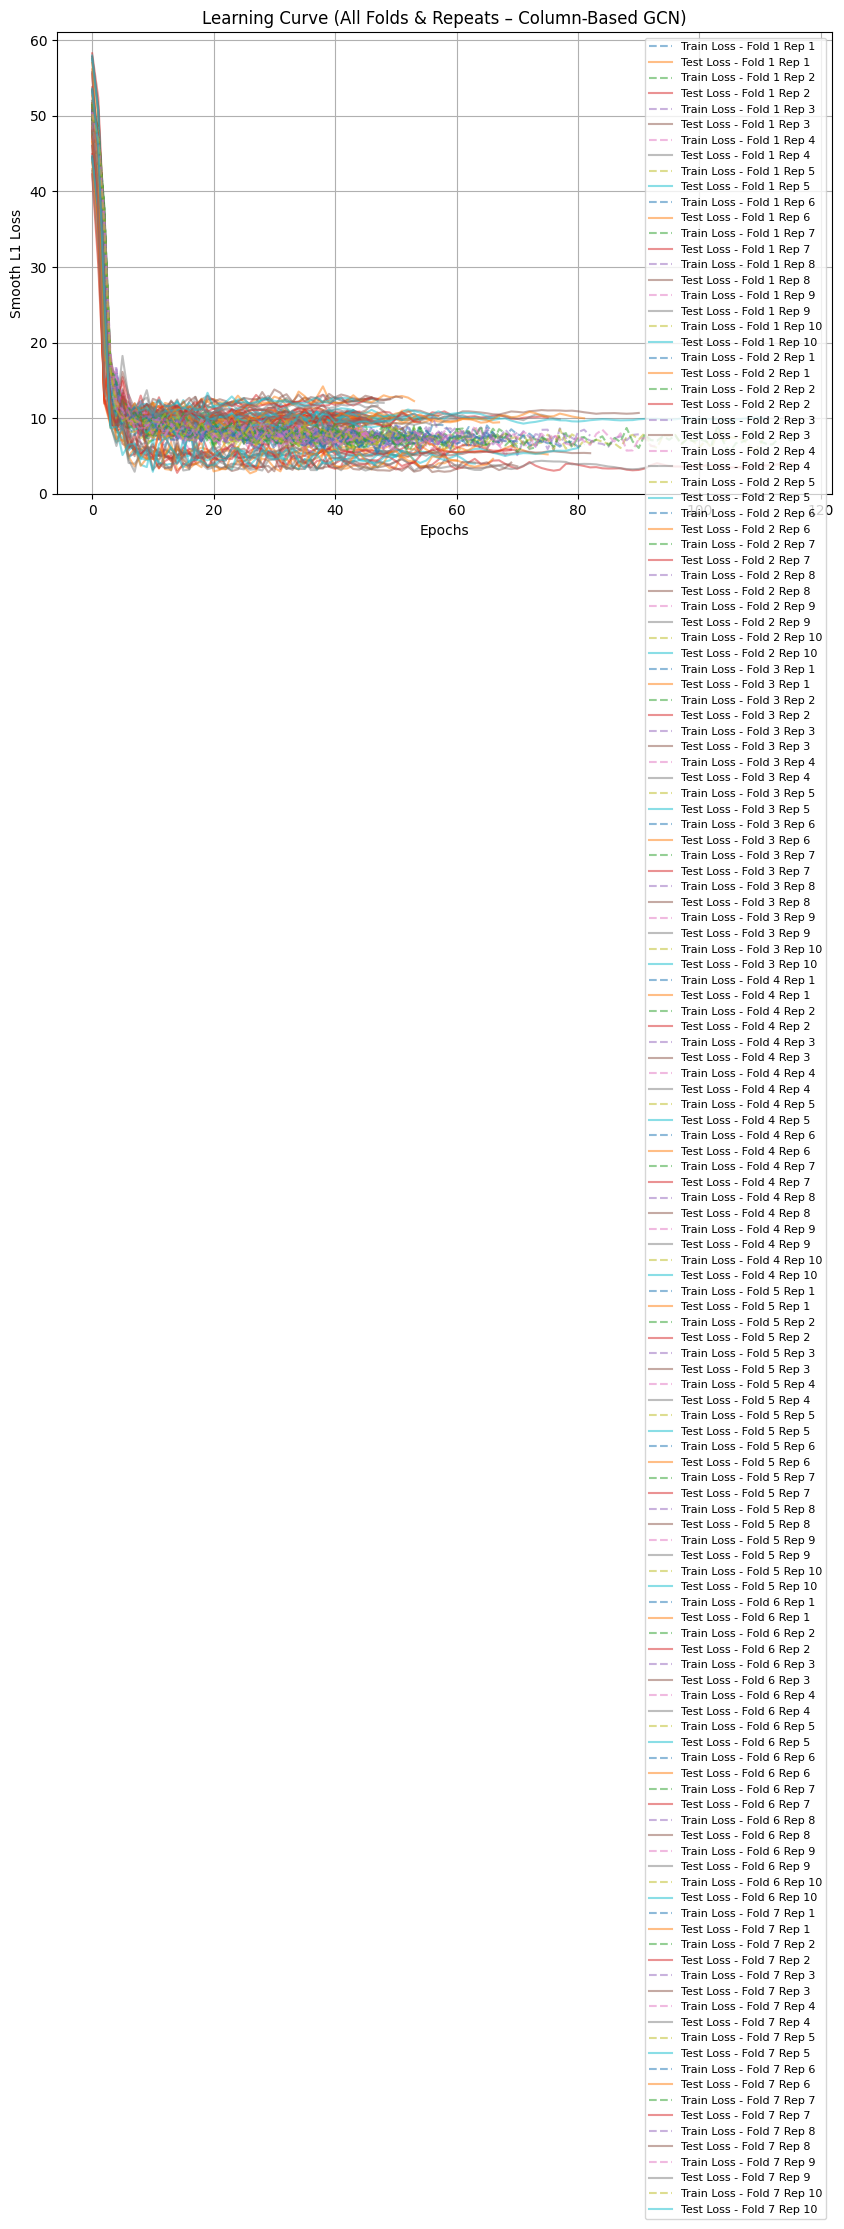

In [59]:
##################  LEARNING CURVE (ALL FOLDS + REPEATS)  ##################

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot learning curves for each fold and repetition
for fold in range(k):
    for rep in range(repeats_per_fold):
        plt.plot(all_train_losses[fold][rep], label=f'Train Loss - Fold {fold+1} Rep {rep+1}', linestyle='dashed', alpha=0.5)
        plt.plot(all_test_losses[fold][rep], label=f'Test Loss - Fold {fold+1} Rep {rep+1}', alpha=0.5)

plt.xlabel("Epochs")
plt.ylabel("Smooth L1 Loss")
plt.title("Learning Curve (All Folds & Repeats – Column-Based GCN)")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


In [60]:
#######################  LEARNING CURVE (MEAN ± STD)  ########################
# Compute mean and std per epoch across all folds and repetitions
avg_train = []
avg_test = []

for epoch in range(epochs):
    epoch_train = []
    epoch_test = []
    for fold in range(k):
        for rep in range(repeats_per_fold):
            if epoch < len(all_train_losses[fold][rep]):
                epoch_train.append(all_train_losses[fold][rep][epoch])
                epoch_test.append(all_test_losses[fold][rep][epoch])
    avg_train.append((np.mean(epoch_train), np.std(epoch_train)))
    avg_test.append((np.mean(epoch_test), np.std(epoch_test)))



d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [61]:
# Unpack values
train_mean, train_std = zip(*avg_train)
test_mean, test_std = zip(*avg_test)

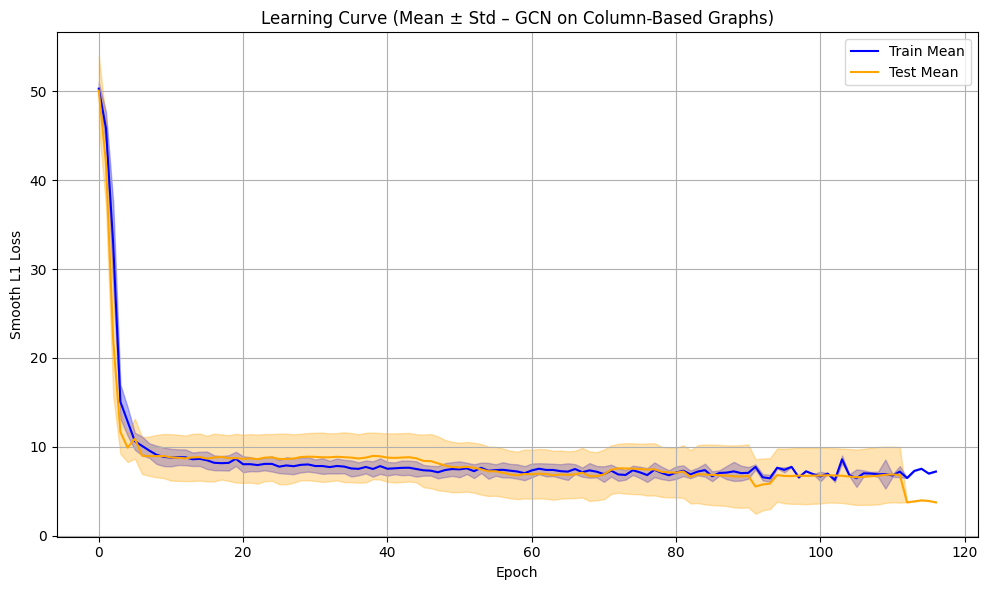

In [62]:
# Plot mean ± std
plt.figure(figsize=(10, 6))

plt.plot(train_mean, label="Train Mean", color="blue")
plt.fill_between(range(epochs), np.array(train_mean) - np.array(train_std),
                 np.array(train_mean) + np.array(train_std), color="blue", alpha=0.3)

plt.plot(test_mean, label="Test Mean", color="orange")
plt.fill_between(range(epochs), np.array(test_mean) - np.array(test_std),
                 np.array(test_mean) + np.array(test_std), color="orange", alpha=0.3)

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 Loss")
plt.title("Learning Curve (Mean ± Std – GCN on Column-Based Graphs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
##################  PREDICTION & METRIC ANALYSIS (THICKNESS-ONLY MODEL)  ##################

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt


# === Initialize storage ===
fold_mae_list = []
fold_r2_list = []
fold_rmse_list = []

all_subject_ids = []
all_y_true = []
all_y_pred = []

# Create a new folder to save the y_true, y_pred, and subject_ids in each fold and repeat
if not os.path.exists("thickness_model_results"):
    os.makedirs("thickness_model_results")

for fold in range(k):
    train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
    test_idx = np.loadtxt(f"../set_split/test_indices_fold_{fold}.csv", delimiter=",", dtype=int)
    print(f"\n=== Evaluating Fold {fold+1}/{k} ===")

    test_data = [thickness_data_list[i] for i in test_idx]
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    train_data = [thickness_data_list[i] for i in train_idx]
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)

    repeat_maes = []
    repeat_r2s = []
    repeat_rmses = []

    for rep in range(repeats_per_fold):
        print(f"  > Repeat {rep+1}/{repeats_per_fold}")

        model = ThicknessNet(thickness_dim=68).to(device)

        model.load_state_dict(torch.load(f"thickness_model_fold_{fold+1}_rep_{rep+1}_ref.pt"))  # Load saved model
        model.eval()

        subject_id_repeat = []
        y_true_repeat = []
        y_pred_repeat = []

        subject_id_repeat_train = []
        y_true_repeat_train = []
        y_pred_repeat_train = []

        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                output = model(data.x).view(-1)
                subject_id_repeat.extend(data.subject_id)
                y_pred_repeat.extend(output.cpu().tolist())
                y_true_repeat.extend(data.y.cpu().tolist())
            # Save predictions and true values to files
            test_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat,
                'y_true': y_true_repeat,
                'y_pred': y_pred_repeat
            })
            test_results_df.to_csv(f"thickness_model_results/fold_{fold+1}_rep_{rep+1}_test_results_ref.csv", index=False)

            for data in train_loader:
                data = data.to(device)
                output = model(data.x).view(-1)
                subject_id_repeat_train.extend(data.subject_id)
                y_pred_repeat_train.extend(output.cpu().tolist())
                y_true_repeat_train.extend(data.y.cpu().tolist())
            # Save predictions and true values for training data
            train_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat_train,
                'y_true': y_true_repeat_train,
                'y_pred': y_pred_repeat_train
            })
            train_results_df.to_csv(f"thickness_model_results/fold_{fold+1}_rep_{rep+1}_train_results_ref.csv", index=False)

        # Compute metrics
        mae = mean_absolute_error(y_true_repeat, y_pred_repeat)
        r2 = r2_score(y_true_repeat, y_pred_repeat)
        rmse = np.sqrt(mean_squared_error(y_true_repeat, y_pred_repeat))

        repeat_maes.append(mae)
        repeat_r2s.append(r2)
        repeat_rmses.append(rmse)

        all_y_true.extend(y_true_repeat)
        all_y_pred.extend(y_pred_repeat)
        all_subject_ids.extend(subject_id_repeat)

    fold_mae_list.append(repeat_maes)
    fold_r2_list.append(repeat_r2s)
    fold_rmse_list.append(repeat_rmses)

    print(f">> Fold {fold+1} | MAE: {np.mean(repeat_maes):.2f} ± {np.std(repeat_maes):.2f} | "
          f"R²: {np.mean(repeat_r2s):.2f} ± {np.std(repeat_r2s):.2f} | "
          f"RMSE: {np.mean(repeat_rmses):.2f} ± {np.std(repeat_rmses):.2f}")



In [64]:
# === Final aggregate results ===
all_maes = np.array(fold_mae_list).flatten()
all_r2s = np.array(fold_r2_list).flatten()
all_rmses = np.array(fold_rmse_list).flatten()

print("\n================== FINAL METRICS (COLUMN-BASED GCN) ==================")
print(f"Global MAE:  {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}")
print(f"Global R²:   {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}")
print(f"Global RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")
print("=======================================================================")



================== FINAL METRICS (COLUMN-BASED GCN) ==================
Global MAE:  7.94 ± 2.11
Global R²:   0.48 ± 0.27
Global RMSE: 9.53 ± 2.43


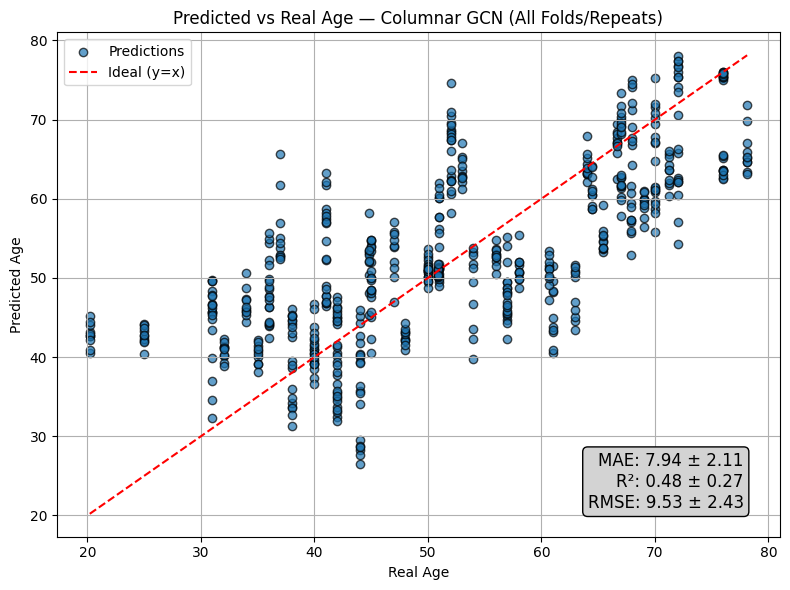

In [65]:
######################  PLOT TRUE VS PREDICTED AGES (COLUMN-BASED)  ######################

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Scatter plot of true vs predicted ages
plt.scatter(all_y_true, all_y_pred, alpha=0.7, edgecolors='k', label="Predictions")


# Diagonal (ideal prediction)
min_val = min(min(all_y_true), min(all_y_pred))
max_val = max(max(all_y_true), max(all_y_pred))
margin = (max_val - min_val) * 0.05
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="dashed", label="Ideal (y=x)")
plt.xlim(min_val - margin, max_val + margin)
plt.ylim(min_val - margin, max_val + margin)


# Metrics text box with MAE, R² and RMSE
textstr = (f"MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}\n"
           f"R²: {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}\n"
           f"RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")

plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

# Labels and style
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age — Columnar GCN (All Folds/Repeats)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()



In [66]:
# Save all_y_true and all_y_pred to CSV
import pandas as pd
# Create a DataFrame from the true and predicted values
# For each subject, there're 7 folds and 10 repeats, so we can flatten the lists and match them
# all_y_true = 67 subjects * 10 repeats * 7 folds = 4690 values
# all_y_pred = 67 subjects * 10 repeats * 7 folds = 4690 values
# Flatten subject IDs if they are lists of lists
def flatten(l):
    return [item for sublist in l for item in sublist] if isinstance(l[0], list) else l

flat_subject_ids = flatten(all_subject_ids)

# Print the length of flat_subject_ids
print(f"Total subjects in flattened list: {len(flat_subject_ids)}")

df_results = pd.DataFrame({
    'subject_id': flat_subject_ids,
    'y_true': all_y_true,
    'y_pred': all_y_pred
})
# Save the mean and std of the predicted ages for each subject
df_results_mean_std = df_results.groupby('subject_id').agg(
    y_true_mean=('y_true', 'mean'),
    y_true_std=('y_true', 'std'),
    y_pred_mean=('y_pred', 'mean'),
    y_pred_std=('y_pred', 'std')
).reset_index()
# Save to CSV
df_results_mean_std.to_csv("column_based_gcn_results_ref.csv", index=False)

Total subjects in flattened list: 590


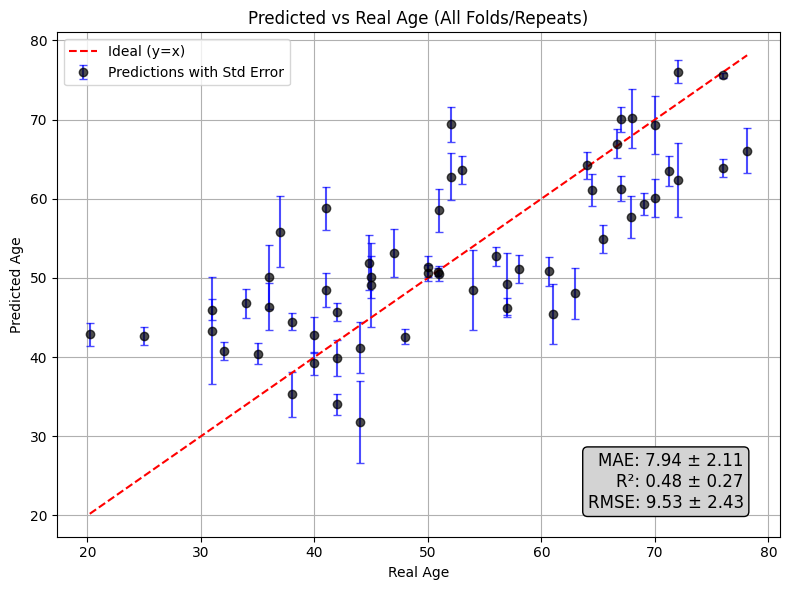

In [67]:
# Plot y_true vs y_pred with error bar being the std of y_pred for each subject
plt.figure(figsize=(8, 6))
plt.errorbar(df_results_mean_std['y_true_mean'], df_results_mean_std['y_pred_mean'],
             yerr=df_results_mean_std['y_pred_std'], fmt='o', alpha=0.7,
             label='Predictions with Std Error', color='black', ecolor='blue',
                capsize=3)
# Diagonal (ideal prediction)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="dashed", label="Ideal (y=x)")
# Metrics text box with MAE, R² and RMSE
textstr = (f"MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}\n"
           f"R²: {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}\n"
           f"RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")

plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

# Labels and style
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age (All Folds/Repeats)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [68]:
############################################

# FINAL MODEL TRAINING ON HEALTHY + FAMILIAL

############################################

print("\n=== Training Final Model on All Healthy + Familial Subjects ===")

from torch_geometric.loader import DataLoader


# === Prepare thickness data for all filtered subjects ===

# === Create DataLoader with all filtered subjects ===
final_train_loader = DataLoader(thickness_data_list, batch_size=6, shuffle=True)


# === Initialize model ===
final_model = ThicknessNet(thickness_dim=68).to(device)


# === Optimizer and learning rate scheduler ===
optimizer = torch.optim.AdamW(final_model.parameters(), lr=0.002, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)


# === Loss function ===
criterion = torch.nn.SmoothL1Loss(beta=1)




=== Training Final Model on All Healthy + Familial Subjects ===


In [69]:
# === Train for fixed number of epochs (no early stopping) ===
epochs = 100

for epoch in range(epochs):
    final_model.train()
    total_loss = 0

    for data in final_train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = final_model(data.x).view(-1)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(final_train_loader)
    print(f"Epoch {epoch+1:03d} | Loss: {avg_loss:.4f}")

    scheduler.step()



Epoch 001 | Loss: 50.4616
Epoch 002 | Loss: 44.7530
Epoch 003 | Loss: 29.0072
Epoch 004 | Loss: 13.5929
Epoch 003 | Loss: 29.0072
Epoch 004 | Loss: 13.5929
Epoch 005 | Loss: 10.1161
Epoch 005 | Loss: 10.1161
Epoch 006 | Loss: 9.5314
Epoch 007 | Loss: 10.0300
Epoch 006 | Loss: 9.5314
Epoch 007 | Loss: 10.0300
Epoch 008 | Loss: 10.1683
Epoch 008 | Loss: 10.1683
Epoch 009 | Loss: 8.2939
Epoch 010 | Loss: 8.3741
Epoch 011 | Loss: 8.9307
Epoch 009 | Loss: 8.2939
Epoch 010 | Loss: 8.3741
Epoch 011 | Loss: 8.9307
Epoch 012 | Loss: 8.9918
Epoch 012 | Loss: 8.9918
Epoch 013 | Loss: 8.1621
Epoch 014 | Loss: 8.7450
Epoch 015 | Loss: 9.0565
Epoch 013 | Loss: 8.1621
Epoch 014 | Loss: 8.7450
Epoch 015 | Loss: 9.0565
Epoch 016 | Loss: 8.4156
Epoch 016 | Loss: 8.4156
Epoch 017 | Loss: 8.2159
Epoch 018 | Loss: 8.2746
Epoch 019 | Loss: 9.7276
Epoch 017 | Loss: 8.2159
Epoch 018 | Loss: 8.2746
Epoch 019 | Loss: 9.7276
Epoch 020 | Loss: 8.1238
Epoch 020 | Loss: 8.1238
Epoch 021 | Loss: 9.0229
Epoch 022 | L

In [70]:
# === Save final model ===
torch.save(final_model.state_dict(), "thickness_model_trained_on_all_healthy_ref.pt")
print("\nFinal model saved as 'thickness_model_trained_on_all_healthy_ref.pt'")




Final model saved as 'thickness_model_trained_on_all_healthy_ref.pt'


In [71]:
# === Notes ===

# We selected 100 epochs for the final model training based on the early stopping

# behavior observed during cross-validation. Most runs converged between 60–90 epochs (mean=86)

# so 100 allows for full convergence without early stopping.

